# Works
# - Todo: calc_classes_numpy() in extra lib
# - Todo: Documentation

In [ ]:
import sys,os,ctypes
from pathlib import Path
import numpy as np
import pandas as pd
import time

import gng_py

In [2]:
from sklearn.datasets import make_blobs, make_circles


n_samples=300
noise=0.05
factor=0.3
random_state=1321


in_set, target = make_circles(
        n_samples=n_samples,
        noise=noise,
        factor=factor,
        random_state=random_state
    )
in_set = in_set.flatten()

In [3]:
ctx = gng_py.PyContext()
ctx.create_system()


ctx.set_parameters(
            input_width = 2,
            weight_rng_min = -1.1,
            weight_rng_max = 1.1,
            edge_removal_age = 50,
            neuron_creation_interval = 200,
            max_train_iterations = 20000,
            target_error = 0.096,
            epsilon_w = 0.1,
            epsilon_n = 0.006,
            alpha = 0.5,
            beta = 0.995,
)


ctx.init_dataset_vec(in_set.flatten())
start = time.time()
ctx.fit()
end = time.time()
model_string = ctx.get_model_string()
print(end-start)

0.40634846687316895


In [4]:
import sys,os
import matplotlib.pyplot as plt
import json

In [5]:
data = json.loads(model_string)

In [6]:
points = None
edges = None
edge_positions = None
rows = []
for neuron in data["model"]["neurons"]:
    position = neuron["position"]
    id = neuron['id']
    x = position[0]
    y = position[1]
    rows.append({"id": id, "x": x, "y": y})

points = pd.DataFrame(rows)
points['class'] = points.index 

# Extract edges
row_edge = []
for edge in data['model']['edges']:
    edge_from = edge['from']
    edge_to = edge['to']
    row_edge.append({"start": edge_from, "to": edge_to})

edges = pd.DataFrame(row_edge)

# Calculate edge positions
row = []
for _, row_edge in edges.iterrows():
    try:
        row_from = points.loc[points['id'] == row_edge['start']].iloc[0]
        x_from = float(row_from['x'])
        y_from = float(row_from['y'])
        row_to = points.loc[points['id'] == row_edge['to']].iloc[0]
        x_to = float(row_to['x'])
        y_to = float(row_to['y'])

        row.append({"x_from": x_from, "y_from": y_from, "x_to": x_to, "y_to": y_to})
    except (IndexError, KeyError):
        continue

#edge_positions = pd.DataFrame(row)



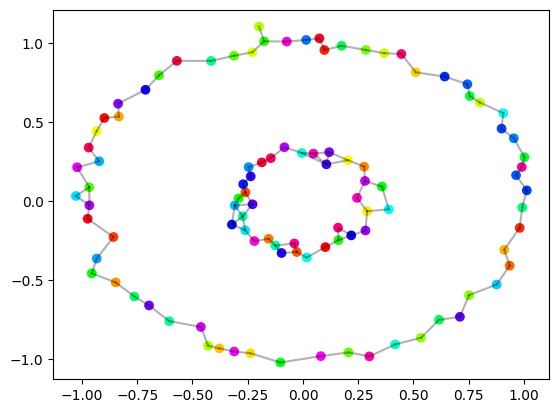

In [7]:
import matplotlib.pyplot as plt
plot = plt.figure()
ax = plot.add_subplot(111)

ax.clear()



# Plot points
ax.scatter(points['x'], points['y'],c=points['class'],cmap='hsv')

# Plot connections
for _, row in edges.iterrows():
    row_from = points.loc[points['id'] == row['start']].iloc[0]
    x_from = float(row_from['x'])
    y_from = float(row_from['y'])
    row_to = points.loc[points['id'] == row['to']].iloc[0]
    x_to = float(row_to['x'])
    y_to = float(row_to['y'])

    ax.plot([x_from, x_to], [y_from, y_to], 'k-', alpha=0.3)

# Class calculation

In [8]:
import numpy as np

def calc_classes_numpy(f_points, f_edges):
    # Extract columns as NumPy arrays
    point_ids = f_points["id"].to_numpy()
    point_class = f_points["class"].to_numpy()

    edge_start = f_edges["start"].to_numpy()
    edge_to    = f_edges["to"].to_numpy()

    num_points = len(point_ids)
    num_edges  = len(edge_start)

    # --- Mapping: point_id -> index ---
    # (Assuming ids are arbitrary integers)
    # Build fast lookup dictionary: id → index
    id_to_index = {pid: i for i, pid in enumerate(point_ids)}

    changed = True
    while changed:
        changed = False

        for p_idx in range(num_points):
            curr_point_id = point_ids[p_idx]

            # Loop edges
            for e in range(num_edges):

                s = edge_start[e]
                t = edge_to[e]

                # Case 1: point is edge start
                if s == curr_point_id:
                    i_s = id_to_index[s]
                    i_t = id_to_index[t]

                    if point_class[i_s] > point_class[i_t]:
                        point_class[i_s] = point_class[i_t]
                        changed = True
                        break

                # Case 2: point is edge end
                if t == curr_point_id:
                    i_s = id_to_index[t]
                    i_t = id_to_index[s]

                    if point_class[i_s] > point_class[i_t]:
                        point_class[i_s] = point_class[i_t]
                        changed = True
                        break

    # Write classes back to DataFrame
    f_points["class"] = point_class
    return f_points

In [9]:
points = calc_classes_numpy(points,edges)

In [10]:
num_classes = points["class"].unique()
print(f"num classes: {num_classes}")

num classes: [0 1]


# Plot with unique class colors

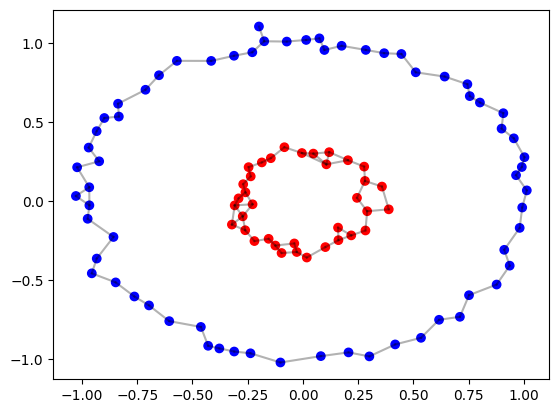

In [11]:
import matplotlib.pyplot as plt
plot = plt.figure()
ax = plot.add_subplot(111)

ax.clear()



# Plot points
import matplotlib as mpl
from matplotlib.colors import ListedColormap

my_norm = mpl.colors.Normalize(vmin=points['class'].min(), 
                            vmax=points['class'].max())
my_map = ListedColormap(["red","blue"])
#ax.scatter(points['x'], points['y'],c=points['class'],cmap='hsv',norm=my_norm)
ax.scatter(points['x'], points['y'],c=points['class'],cmap=my_map,norm=my_norm)

# Plot connections
for _, row in edges.iterrows():
    row_from = points.loc[points['id'] == row['start']].iloc[0]
    x_from = float(row_from['x'])
    y_from = float(row_from['y'])
    row_to = points.loc[points['id'] == row['to']].iloc[0]
    x_to = float(row_to['x'])
    y_to = float(row_to['y'])

    ax.plot([x_from, x_to], [y_from, y_to], 'k-', alpha=0.3)
plt.show()